In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import *
from MODELS.teamInfo import *


In [2]:
q10_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q10_modelv2.pkl')
q50_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q50_modelv2.pkl')
q90_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q90_modelv2.pkl')
models = {'q10': q10_model, 'q50': q50_model, 'q90': q90_model}
features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

In [3]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')

df = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')

date = '2024-12-12'

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'underdog') &  (backtestData['CATEGORY'] == 'player_points')]
backtestData.sample(5)


/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_13801/1633982547.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
9554,9554,9554,9554,Kelly Oubre Jr,player_points,underdog,over,14.5,-137,Phoenix Suns,Philadelphia 76ers,f5d380ca5f80d45b776b8cc4365ef870,2024-11-05T03:15:00Z,2024-11-04,NaN,NaN,NaN,over
196004,196004,196004,116775,Kyle Kuzma,player_points,underdog,under,18.5,-137,Milwaukee Bucks,Detroit Pistons,NaN,NaN,2025-04-13,game,25.0,100.0,under
84862,84862,84862,84862,Ivica Zubac,player_points,underdog,under,14.5,-137,Milwaukee Bucks,Los Angeles Clippers,NaN,NaN,2025-02-21,game,15.5,100.0,under
176561,176561,176561,92546,T. Vukcevic,player_points,underdog,under,13.5,-137,Washington Wizards,Orlando Magic,NaN,NaN,2025-04-03,game,12.5,-103.0,under
57264,57264,57264,57264,Nicolas Batum,player_points,underdog,under,3.5,-137,Toronto Raptors,Los Angeles Clippers,NaN,NaN,2025-02-02,game,3.5,-107.0,under


In [5]:
results = backtestPairs(
    data=df,
    backtestData=backtestData,
    gameDate='2024-12-15',
    models=models,  
    features=features,
    edge_threshold=0.18, 
    top_n=15, 
    variance_inflation=1.1, 
    distribution_type='skew_t', stat_col='PTS', 
    use_monte_carlo=True, n_simulations=1000, max_kelly=0.25, stake=10)

# Comprehensive results analysis
if not results.empty:
    print("=" * 60)
    print("PAIR BETTING RESULTS ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Calculate profit/loss
    total_profit = results['pair_profit'].sum()
    avg_profit = results['pair_profit'].mean()
    
    print(f"Total Bets: {total_bets}")
    print(f"Wins: {total_wins}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total Profit: ${total_profit:.2f}")
    print(f"Average Profit per Bet: ${avg_profit:.2f}")

results

Starting backtest for pairs on 2024-12-15
Time taken for pairs: 12.457676887512207 seconds
Time taken for sorting: 12.4617338180542 seconds
Time taken for dropping duplicates: 12.469229936599731 seconds
Time taken for iterating over evData: 12.469258069992065 seconds
Time taken for backtest_results: 12.683802843093872 seconds
PAIR BETTING RESULTS ANALYSIS
Total Bets: 26
Wins: 16
Win Rate: 61.54%
Total Profit: $220.00
Average Profit per Bet: $8.46


,player1,player2,model_side1,model_side2,line1,line2,pred1,pred2,q10_1,q90_1,q10_2,q90_2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_won,pair_recommendation,pair_profit,ev_percent,kelly_full,kelly_capped,kelly_bet_size,kelly_bet_size_full,stake,prob_both,combined_edge,simulation_method,selection,date
0,Jalen Suggs,Rui Hachimura,under,under,21.5,13.5,14.78,8.48,7.23,25.35,3.15,17.78,9,8,0.244,0.232,1,1,1,1,20.0,1.00,0.499,0.25,2.5,4.99,10,0.6658,0.238,Monte Carlo,top_ev,2024-12-15
1,Jalen Suggs,Jordan Poole,under,under,21.5,22.5,14.78,16.42,7.23,25.35,7.63,28.62,9,21,0.244,0.211,1,1,1,1,20.0,0.95,0.473,0.25,2.5,4.73,10,0.6486,0.227,Monte Carlo,top_ev,2024-12-15
2,Jordan Poole,Rui Hachimura,under,under,22.5,13.5,16.42,8.48,7.63,28.62,3.15,17.78,21,8,0.211,0.232,1,1,1,1,20.0,0.92,0.459,0.25,2.5,4.59,10,0.6391,0.221,Monte Carlo,top_ev,2024-12-15
3,Jalen Suggs,Anthony Davis,under,under,21.5,28.5,14.78,22.91,7.23,25.35,13.14,33.44,9,40,0.244,0.198,1,0,0,1,-10.0,0.91,0.457,0.25,2.5,4.57,10,0.6379,0.221,Monte Carlo,top_ev,2024-12-15
4,Jordan Poole,Anthony Davis,under,under,22.5,28.5,16.42,22.91,7.63,28.62,13.14,33.44,21,40,0.211,0.198,1,0,0,1,-10.0,0.84,0.418,0.25,2.5,4.18,10,0.6123,0.204,Monte Carlo,top_ev,2024-12-15
5,Jalen Suggs,Austin Reaves,under,under,21.5,17.5,14.78,13.76,7.23,25.35,4.79,23.67,9,19,0.244,0.132,1,0,0,1,-10.0,0.75,0.375,0.25,2.5,3.75,10,0.5836,0.188,Monte Carlo,top_ev,2024-12-15
6,Kentavious Caldwell-Pope,Rui Hachimura,under,under,9.5,13.5,6.76,8.48,1.54,15.01,3.15,17.78,4,8,0.137,0.232,1,1,1,1,20.0,0.74,0.369,0.25,2.5,3.69,10,0.5792,0.184,Monte Carlo,top_ev,2024-12-15
7,Anthony Black,Rui Hachimura,under,under,9.5,13.5,6.77,8.48,1.13,14.56,3.15,17.78,4,8,0.137,0.232,1,1,1,1,20.0,0.74,0.369,0.25,2.5,3.69,10,0.5792,0.184,Monte Carlo,top_ev,2024-12-15
8,Jalen Suggs,Victor Wembanyama,under,under,21.5,22.5,14.78,18.46,7.23,25.35,10.81,32.42,9,20,0.244,0.122,1,1,1,1,20.0,0.73,0.363,0.25,2.5,3.63,10,0.5754,0.183,Monte Carlo,top_ev,2024-12-15
9,Jalen Suggs,Stephen Curry,under,under,21.5,25.5,14.78,21.81,7.23,25.35,11.07,32.14,9,26,0.244,0.115,1,0,0,0,-10.0,0.71,0.354,0.25,2.5,3.54,10,0.5696,0.179,Monte Carlo,top_ev,2024-12-15


## Points

In [ ]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPairs(
        data=df,
        backtestData=backtestData,
        gameDate=date,
        models=models,  
        features=features,
        edge_threshold=0.12, 
        top_n=15, 
        variance_inflation=1.1, 
        distribution_type='skew_t', stat_col='PTS', 
        use_monte_carlo=False, n_simulations=10000, max_kelly=0.25, stake=100)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 2,573
   Wins: 934
   Hit Rate: 36.30%
   Total Profit: $1,145.00
   Total Staked: $12,865.00
   ROI: 8.90%
   Volatility: $66.05
   Max Drawdown: $-610.00
   Sharpe Ratio: 1.492

 RECOMMENDED BETS ANALYSIS (Edge > 0.20):
   Total Bets: 1,906
   Wins: 706
   Hit Rate: 37.04%
   Total Profit: $1,060.00
   Total Staked: $9,530.00
   ROI: 11.12%
   Volatility: $63.56
   Max Drawdown: $-445.00
   Sharpe Ratio: 1.562


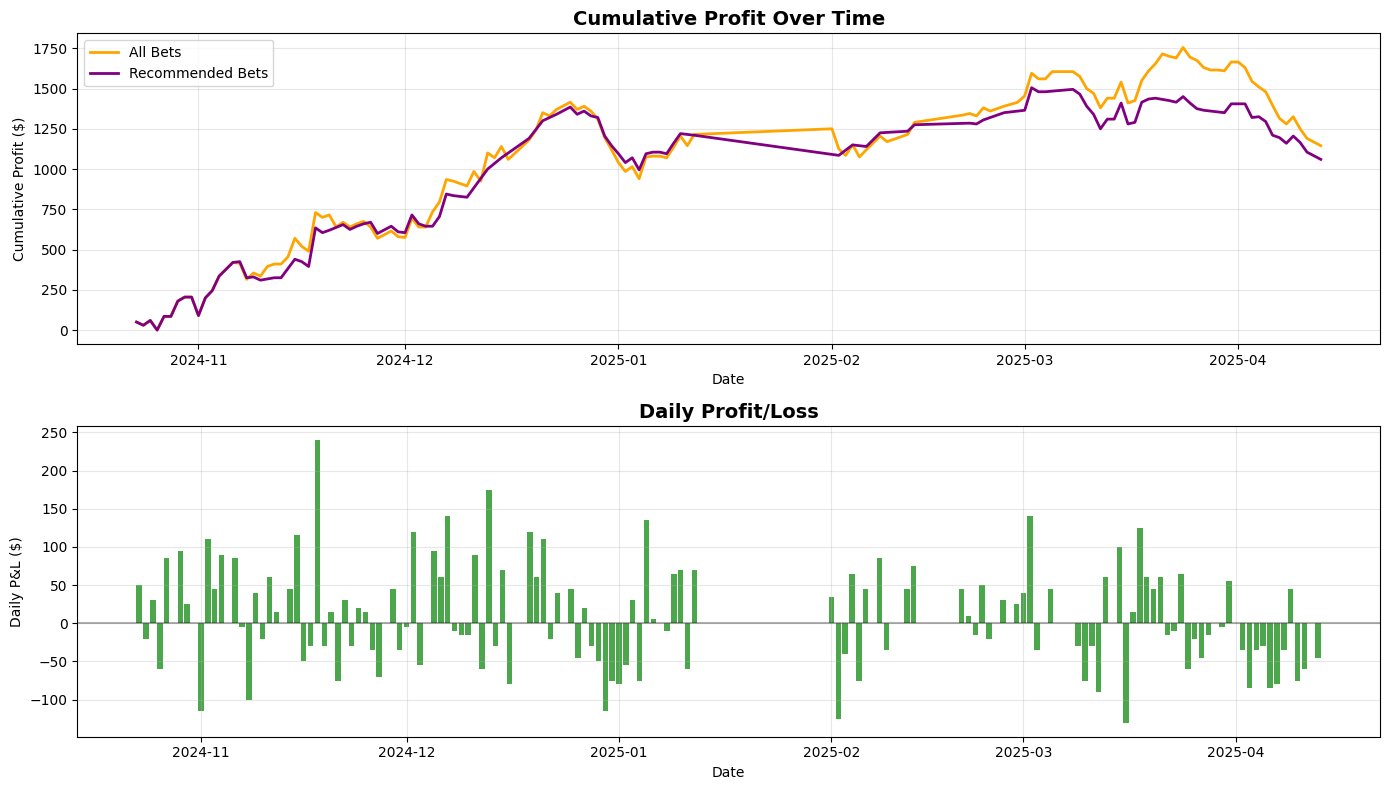

In [9]:
final_results = pd.read_csv('underdog.csv')
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print("\n RECOMMENDED BETS ANALYSIS (Edge > 0.20):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [18]:
# Calculate win rates by category
category_analysis = final_results.groupby('selection').agg({
    'stake': 'sum',
    'pair_recommendation': 'sum', 
    'pair_profit': 'sum',
    'pair_won': 'sum'  # This column needs to exist
}).reset_index()

# Calculate win rates
category_analysis['total_bets'] = len(final_results)
category_analysis['win_rate'] = category_analysis['pair_won'] / category_analysis['pair_recommendation']
category_analysis['roi'] = category_analysis['pair_profit'] / category_analysis['stake']

print("Win Rates by Category:")
print(category_analysis[['selection', 'total_bets','pair_recommendation', 'pair_won', 'win_rate']])

Win Rates by Category:
   selection  total_bets  pair_recommendation  pair_won  win_rate
0     top_ev        2573                 1369       719  0.525201
1  top_kelly        2573                  537       215  0.400372
